# CW-ODMR

Plan for this notebook (building it up in stages):

1. **Resonator tuning (this section)** -- the resonator's tuning screw is manual, so this
   is an interactive loop: turn the screw a bit, take a quick NanoVNA sweep, look at where
   the S11 dip landed, repeat. No microwave source or laser needed for this part -- just
   the NanoVNA on the resonator's coupling port.
2. Once the resonator is close, do a coarse-then-fine sweep with the HP8673H + E4403B
   (`hp8673h.py`'s `resonance_sweep()`) to pin down the exact drive frequency and Q.
3. With the interlock running, power on the microwaves at that frequency, leave the laser
   on continuously, and record PL -- several long RTB2004 segments -- while sweeping (or
   sitting at) the MW frequency.

This first pass only covers step 1: taking data with the NanoVNA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nanovna import NanoVNAF3

vna = NanoVNAF3(debug=True)
print(vna.read_version())
print(vna.read_info())

RuntimeError: NanoVNA not found on any USB-CDC port -- pass port= explicitly (e.g. NanoVNAF3(port='COM5'))

## Resonator tuning loop

Fixed 2-4 GHz sweep range. Re-run the cell below after each turn of the tuning screw --
no need to reconnect or re-run the cells above.

In [2]:
START_HZ = 2e9
STOP_HZ = 4e9
POINTS = 801  # NanoVNA-F V3's max

In [3]:
# Re-run this cell after each screw adjustment.
freqs_hz, data = vna.sweep(START_HZ, STOP_HZ, POINTS, channels=(0,))
s11_db = 20 * np.log10(np.abs(data[0]))

dip_idx = np.argmin(s11_db)
dip_freq_hz = freqs_hz[dip_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_hz / 1e9, s11_db)
ax.axvline(dip_freq_hz / 1e9, color="C1", ls="--", label=f"dip: {dip_freq_hz/1e9:.4f} GHz")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("S11 (dB)")
ax.set_title("resonator reflection -- adjust the tuning screw and re-run")
ax.legend()
fig.tight_layout()

print(f"dip at {dip_freq_hz/1e9:.4f} GHz, depth {s11_db[dip_idx]:.1f} dB")

NameError: name 'vna' is not defined

Once the dip sits at the target frequency (adjust `CENTER_HZ`/`SPAN_HZ` and re-run as it
gets close, to zoom in), save a final sweep of the tuned resonator for the record.

In [4]:
import os
os.makedirs("data", exist_ok=True)
vna.run(START_HZ, STOP_HZ, POINTS, channels=(0,), path="data", name="resonator_tuned")

NameError: name 'vna' is not defined

In [5]:
vna.close()

NameError: name 'vna' is not defined

## Step 2: coarse-then-fine resonance sweep (HP8673H + E4403B)

Now that there's an amplifier in the path (between the HP8673H and the resonator),
`power_dbm` drops from the `0.0` dBm used previously to **-40 dBm** -- the amplifier's
gain means -40 dBm in still ends up as real power at the resonator/coupler, and 0 dBm in
would very likely overdrive the amplifier and/or saturate the E4403B's input.

Uses `hp8673h.py`'s `resonance_sweep()` (coarse sweep across [`START_HZ`, `STOP_HZ`] to
find the dip, then a narrow/dense sweep around it for a precise f0/Q). See `notes.md` for
why the coarse step size should track the expected FWHM (default here assumes Q~75 --
retune `COARSE_STEP_HZ` if the resonator's Q is very different).

In [6]:
from hp8673h import HP8673H
from e4403b import E4403B

# See notes.md -- GPIB bus numbering isn't stable, confirm with
# pyvisa.ResourceManager().list_resources() if these don't match.
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

HP8673H: connected
E4403B: connected


In [7]:
import os

RES_START_HZ = 2.0e9
RES_STOP_HZ = 3.0e9
COARSE_STEP_HZ = 6.7e6   # assumes Q~75; retune if the resonator's Q is very different
FINE_SPAN_HZ = 20e6
FINE_STEP_HZ = 50e3
POWER_DBM = -40.0        # amplifier in the path now -- was 0.0 dBm before

os.makedirs("data", exist_ok=True)
result = gen.resonance_sweep(
    sa, RES_START_HZ, RES_STOP_HZ, COARSE_STEP_HZ, FINE_SPAN_HZ, FINE_STEP_HZ,
    POWER_DBM, output_prefix="data/resonance_m40dbm",
)

[resonance_sweep] coarse sweep 2.0000-3.0000 GHz, step 6.70 MHz, -40.0 dBm


[resonance_sweep] coarse dip: 2.1005 GHz, -42.7 dBm
[resonance_sweep] fine sweep around 2.1005 GHz, span 20.00 MHz, step 50.0 kHz


[resonance_sweep] f0 = 2.09070 GHz, depth = 2.6 dB, FWHM = 0.40 MHz, Q ~= 5227


f0 = 2.09070 GHz, depth = 2.6 dB, FWHM = 0.40 MHz, Q ~= 5227


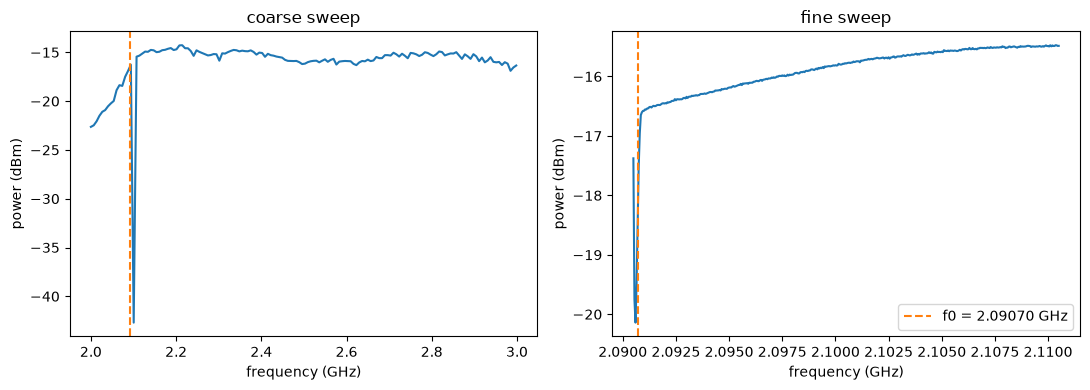

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(result["coarse_freqs_hz"] / 1e9, result["coarse_power_dbm"])
axes[0].axvline(result["f0_hz"] / 1e9, color="C1", ls="--")
axes[0].set_xlabel("frequency (GHz)")
axes[0].set_ylabel("power (dBm)")
axes[0].set_title("coarse sweep")

axes[1].plot(result["fine_freqs_hz"] / 1e9, result["fine_power_dbm"])
axes[1].axvline(result["f0_hz"] / 1e9, color="C1", ls="--", label=f"f0 = {result['f0_hz']/1e9:.5f} GHz")
axes[1].set_xlabel("frequency (GHz)")
axes[1].set_ylabel("power (dBm)")
axes[1].set_title("fine sweep")
axes[1].legend()

fig.tight_layout()

depth_db = result["baseline_dbm"] - result["dip_dbm"]
print(f"f0 = {result['f0_hz']/1e9:.5f} GHz, depth = {depth_db:.1f} dB, "
      f"FWHM = {result['fwhm_hz']/1e6:.2f} MHz, Q ~= {result['Q']:.0f}")

In [9]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()

## Step 2b: amplifier gain check

Physical setup change: the amplifier's **output** is now connected directly to the
E4403B (bypassing the resonator entirely), so whatever the analyzer reads back at each
frequency is the amplifier's actual output power for a known input power -- gain(f) =
measured_power_dbm(f) - input_power_dbm. Sweeping 2-3 GHz at **-30 dBm** input this time
(a plain frequency_sweep(), not a resonance_sweep() -- there's no dip to find here).

In [10]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

HP8673H: connected
E4403B: connected


In [11]:
GAIN_START_HZ = 2.0e9
GAIN_STOP_HZ = 3.0e9
GAIN_STEP_HZ = 5e6
INPUT_POWER_DBM = -30.0

sa.set_center_span((GAIN_START_HZ + GAIN_STOP_HZ) / 2, GAIN_STOP_HZ - GAIN_START_HZ)
freqs_hz, output_power_dbm = gen.frequency_sweep(
    sa, GAIN_START_HZ, GAIN_STOP_HZ, GAIN_STEP_HZ, power_dbm=INPUT_POWER_DBM,
)
gain_db = output_power_dbm - INPUT_POWER_DBM

gain: mean 24.10 dB, min 16.82 dB, max 25.64 dB, flatness (max-min) 8.81 dB


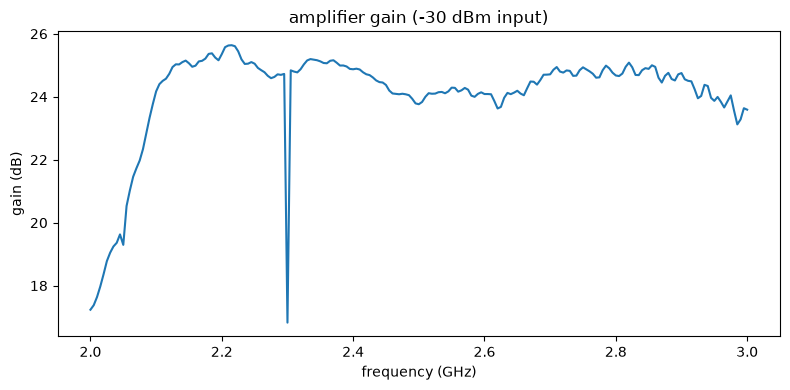

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_hz / 1e9, gain_db)
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("gain (dB)")
ax.set_title(f"amplifier gain ({INPUT_POWER_DBM:.0f} dBm input)")
fig.tight_layout()

print(f"gain: mean {gain_db.mean():.2f} dB, min {gain_db.min():.2f} dB, "
      f"max {gain_db.max():.2f} dB, flatness (max-min) {np.ptp(gain_db):.2f} dB")

np.savetxt(
    "data/amplifier_gain_m30dbm.csv",
    np.column_stack([freqs_hz, output_power_dbm, gain_db]),
    delimiter=",", header="frequency_hz,output_power_dbm,gain_db", comments="",
)

In [13]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()